<a href="https://colab.research.google.com/github/nebojsa-bozanic/BMI_OSuM/blob/dev/04_toniranje.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1>Obrada slike u medicini (BMI)</h1>

Literatura: https://moodle.telekom.ftn.uns.ac.rs/course/view.php?id=82


Laboratorijska vežba 9: Obrada rendgenske slike: Toniranje snimaka

Potrebne biblioteke: cv2, numpy, matplotlib.pyplot, pydicom, osum

In [1]:
!git clone https://github.com/nebojsa-bozanic/BMI_OSuM.git
%cd /content/BMI_OSuM

Cloning into 'BMI_OSuM'...
remote: Enumerating objects: 991, done.
remote: Counting objects: 100% (231/231), done.
remote: Compressing objects: 100% (129/129), done.
remote: Total 991 (delta 166), reused 101 (delta 101), pack-reused 760 (from 1)
Receiving objects: 100% (991/991), 255.50 MiB | 21.73 MiB/s, done.
Resolving deltas: 100% (425/425), done.
/content/BMI_OSuM


In [2]:
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 66.4 MB/s eta 0:00:00


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pydicom
import cv2

In [4]:
import sys
sys.path.append('/content/BMI_OSuM/utils')
import osum

# 1. Logaritamska kompresija i MSE

1.1 Učitati sirovu sliku Ro_01.fxd i uraditi logaritamsku kompresiju opsega (im_log).

In [5]:
!gdown "https://drive.google.com/uc?id=1F-1HFkK_mZ6kNsPq3bvekFqaWv1XJ_dL"

Downloading...
From: https://drive.google.com/uc?id=1F-1HFkK_mZ6kNsPq3bvekFqaWv1XJ_dL
To: /content/BMI_OSuM/Ro_01.fxd
100% 18.9M/18.9M [00:00<00:00, 75.1MB/s]


Text(0.5, 1.0, 'Logaritamska kompresija opsega')

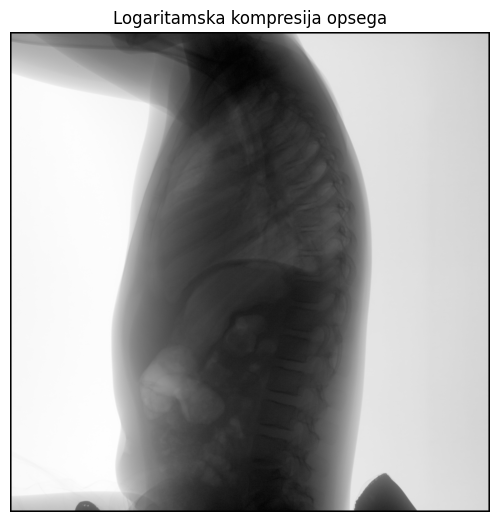

In [6]:
# 1.1
[im, DetInfo, hdr] = osum.read_raw('Ro_01.fxd')

logLUT = osum.log_LUT(16384, 4096, 0.001)
im_log = logLUT[im]

fig = plt.figure()
ax = fig.add_axes([0,0,1,1])
ax.imshow(im_log, cmap='gray', vmin=im_log.min(), vmax=im_log.max())
plt.axis('off')
plt.title('Logaritamska kompresija opsega')

1.2 Od slike im_log napraviti Laplasovu piramidu od 4 nivoa.

In [7]:
def im_pyr_decomp(im, N):

    size_vec  = im.shape
    red_faktor = 2**N
    add_size = np.flip([int((np.ceil(el / red_faktor) * red_faktor - el)) for el in im.shape])
    [v, s] = im.shape
    opim = np.zeros((add_size[1] + v, add_size[0] + s))
    opim[0: v, 0: s] = im
    opim[v + 1: v + add_size[1], :] = opim[v:v-add_size[1]+1:-1, :]
    opim[:, s + 1: s + add_size[0]] = opim[:, s:s - add_size[0] + 1:-1]
    im = opim

    # Funkcija pravi Gausovu i Laplasovu piramidu od N nivoa od slike im
    GPyr = []
    LPyr = []
    for i in range(N):
        GPyr.append(im)
        g = cv2.pyrDown(im, borderType=cv2.BORDER_REPLICATE)
        g_up = cv2.pyrUp(g, cv2.BORDER_REPLICATE)


        l = im - g_up
        LPyr.append(l)
        im = g
    Res = im
    return LPyr, GPyr, Res, size_vec

In [8]:
# 1.2
Lpyr, Gyr, Res, size_vec = im_pyr_decomp(im_log, 4)

1.3 Detalje na prvom nivou pojačati sigmoidalnom transformacijom sa direktnim
potiskivanjem šuma (lazni opseg -2000 do 2000, izlazni opseg -800 do 800, nagib 7 i ukupno 10 % vrednosti oko nule suzbiti). Detalje na drugom nivou pojačati
sigmoidalnom transformacijom sa ublaženim pojačanjem (isti parametri kao
prethodno). Na treći i četvrti nivo primeniti običnu sigmoidalnu transformaciju, ali detalje na trećem pojačati više (nagib 7) nego na četvrtom nivou (nagib 3).

In [9]:
# 1.3
sigLUT_z = osum.sigmLUT_z(2000, 800, 7, 0.05)
sigLUT_lin = osum.sigmLUT_lin(2000, 800, 7, 0.05)
sigLUT1 = osum.sigmLUT(2000, 800, 7)
sigLUT2 = osum.sigmLUT(2000, 800, 3)

Lpyr[0] = sigLUT_z[np.uint16(Lpyr[0]+2000)]
Lpyr[1] = sigLUT_lin[np.uint16(Lpyr[1]+2000)]
Lpyr[2] = sigLUT1[np.uint16(Lpyr[2]+2000)]
Lpyr[3] = sigLUT2[np.uint16(Lpyr[3]+2000)]

1.4 Rekonstruisati ovako izmenjenu piramidu u sliku im_mse i prikazati tu sliku.

In [10]:
def im_pyr_recon(LPyr, Res, size_vec):
    # Funkcija rekonstruise sliku na osnovu Laplasove piramide i reziduala

    # dubina razlaganja
    N = len(LPyr)
    for i in range(N, 0, -1):

        Res = cv2.pyrUp(Res, cv2.BORDER_REFLECT)+LPyr[i-1]

    Res = Res[0:size_vec[0], 0:size_vec[1]]
    im_rec = Res
    return im_rec

Text(0.5, 1.0, 'MSE')

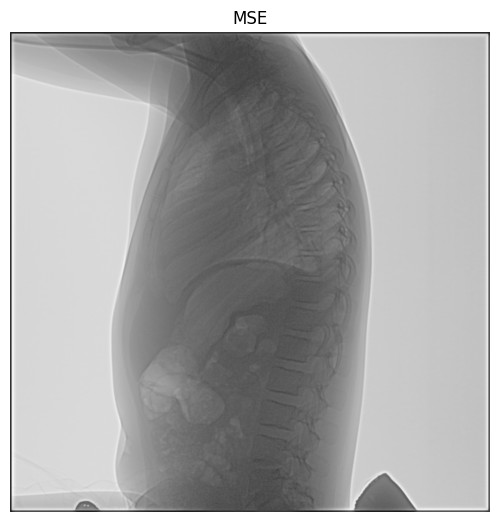

In [11]:
# 1.4
im_mse = im_pyr_recon(Lpyr, Res, size_vec)

fig = plt.figure()
ax = fig.add_axes([0,0,1,1])
ax.imshow(im_mse, cmap='gray', vmin=im_mse.min(), vmax=im_mse.max())
plt.axis('off')
plt.title('MSE')

# 2. Linearno toniranje

2.1 Napraviti i prikazati histogram im_mse.

Text(0.5, 1.0, 'Histogram MSE slike')

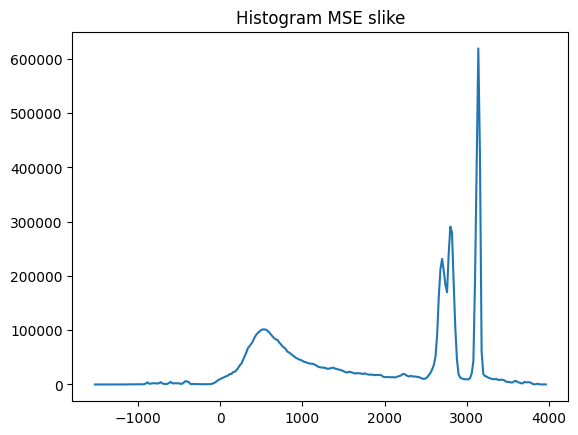

In [12]:
# 2.1
g = np.arange(round(im_mse.min()), round(im_mse.max())+1, 20)
h = np.histogram(im_mse, g)
plt.figure()
plt.plot(g[:-1], h[0])
plt.title('Histogram MSE slike')

2.2 Vizuelnom analizom histograma odraditi granice za toniranje.

In [13]:
# 2.2
Lmin = -350
Lmax = 3000

2.3 Primeniti granice toniranja tako da sve ispod donje i sve iznad gornje ode u zasićenje. Takođe invertovati sliku kako bi se dobio uobičajeni prikaz rtg slike i korigovati izlazni opseg na [0, 255]. Dobijenu sliku nazvati im_ts1. Prikazati sliku.

2.4 Prikazati sliku im_ts1.

Text(0.5, 1.0, 'Linearno toniranje 1')

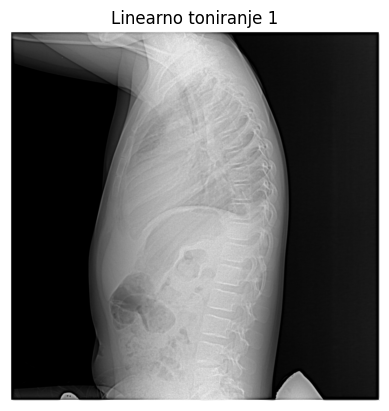

In [14]:
# 2.3
im_ts1  =im_mse
im_ts1[im_ts1<Lmin] = Lmin
im_ts1[im_ts1>Lmax] = Lmax
im_ts1 = (1-osum.im_norm(im_ts1))*255

# 2.4
plt.figure()
plt.imshow(im_ts1, cmap='gray', vmin=im_ts1.min(), vmax=im_ts1.max())
plt.axis('off')
plt.title('Linearno toniranje 1')

2.5 Napraviti kumulativnu sumu normalizovanog histograma i analizirati je paralelno sa normalizovanim histogramom. Šta predstavljaju vrednosti na ovom grafiku?

2.6 U modulu osum napraviti funkciju stat_hist_lims_fromh koja vraća granice intenziteta za toniranje na osnovu prosleđene količine (procenta) najsvetlijih i najtamnijih piksela koje želimo da odvedemo u zasićenje. Ulazni parametri funkcije su još i normalizovani histogram i vektor granica histograma.

Text(0.5, 1.0, 'Kumulativni histogram')

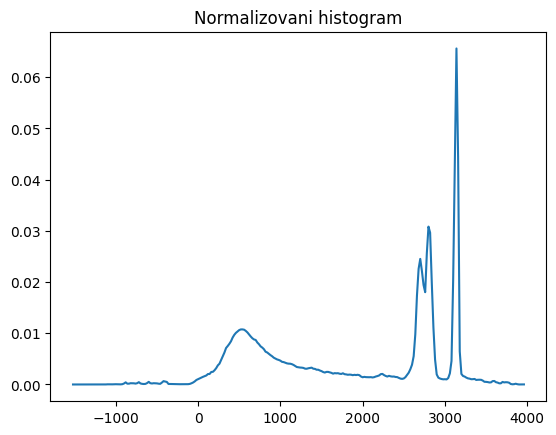

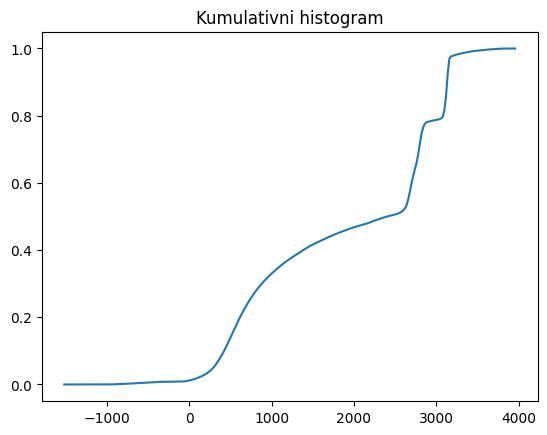

In [15]:
# 2.5
hn = h[0]/np.sum(h[0])
ch = np.cumsum(hn)
plt.figure()
plt.plot(g[:-1], hn)
plt.title('Normalizovani histogram')

plt.figure()
plt.plot(g[:-1], ch)
plt.title('Kumulativni histogram')

2.7 Pomoću funckije napravljene u prethodnom koraku pronaći Lmin i Lmax tako da se 0.1% najtamnijih i 1% najsvetlijih intenziteta odvede u zasićenje (isporbati posle različite parametre i pratit promene). Koliko se razlikuju ovako dobijene vrednosti Lmin i Lmax i one korišćene u 2.2? Koristeći ove granice tonirati sliku (kao u 2.3) i smestiti je u promenljivu im_ts2. Prikazati sliku.

Text(0.5, 1.0, 'Linearno toniranje 2')

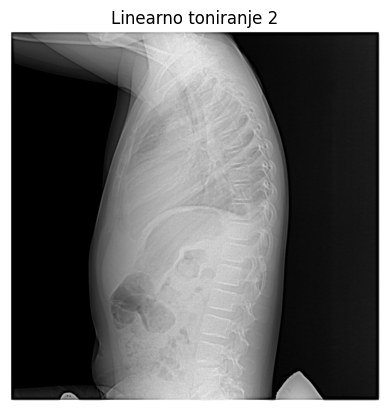

In [16]:
# 2.7
limits = osum.stat_hist_lims_fromh(hn, g[:-1], [0.001, 0.01])
Lmin = limits[0]
Lmax = limits[1]

im_ts2 = im_mse
im_ts2[im_ts2<Lmin] = Lmin
im_ts2[im_ts2>Lmax] = Lmax
im_ts2 = np.uint8((1-osum.im_norm(im_ts2))*255)

plt.figure()
plt.imshow(im_ts2, cmap='gray')
plt.axis('off')
plt.title('Linearno toniranje 2')

2.8 Učitati DICOM fajl 00044.dcm i istonirati CT sliku koja se nalazi u njemu koristeći vrednosti atributa W (WindowWidth) i L (WindowCenter). Slika se tonira tako da se zadrži opseg sa centrom u L širine W, a ostatak se odvodi u zasićenje. Takođe je u pitanju linearno toniranje, ali se Lmin i Lmax indirektno definišu, preko L i W. Prikazati sliku pre i nakon toniranja. Da li se poboljšao prikaz nakon toniranja?

In [17]:
!gdown "https://drive.google.com/uc?id=1kBEagv28ltEk3QWM4EKcB_FW0zuVlIDq"

Downloading...
From: https://drive.google.com/uc?id=1kBEagv28ltEk3QWM4EKcB_FW0zuVlIDq
To: /content/BMI_OSuM/00044.dcm
100% 100k/100k [00:00<00:00, 85.5MB/s]


WindowWidth  (W) = 350.0
WindowCenter (L) = 50.0
Lmin = -125.0
Lmax = 225.0


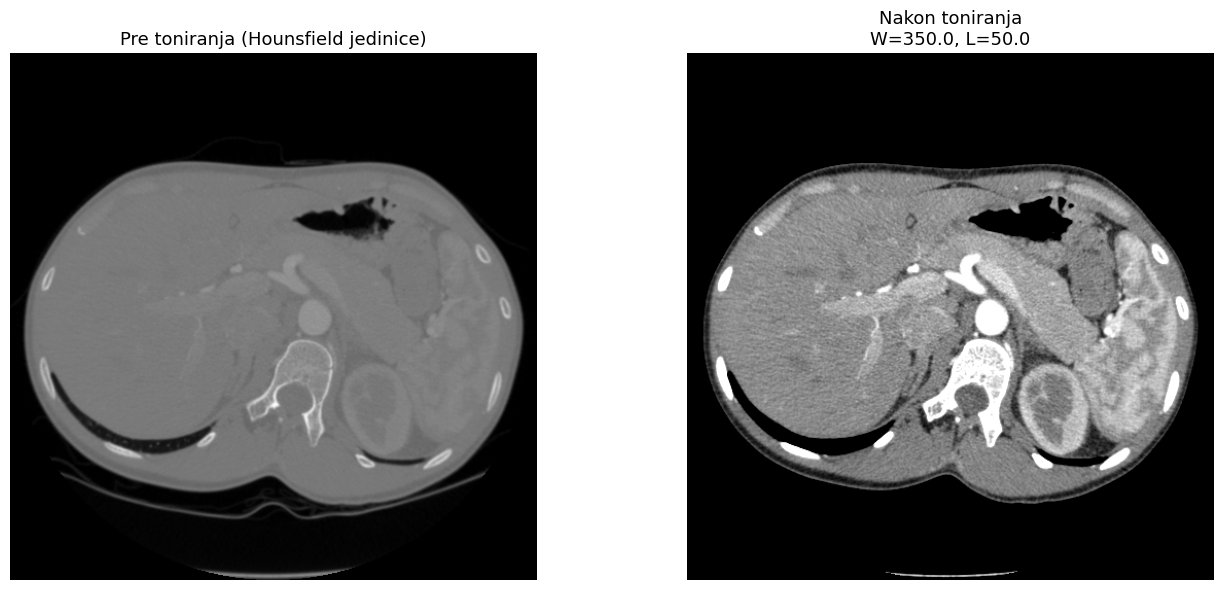

  Opseg pre toniranja: [-1000.0, 1228.0] HU
  Opseg nakon toniranja: [0, 255] (normalizovano)
  Toniranje poboljšava prikaz jer ističe klinički relevantan opseg tkiva.


In [18]:
# 2.8
# Učitavanje DICOM fajla
ds = pydicom.dcmread("00044.dcm")

# Originalna piksel matrica
img = ds.pixel_array.astype(np.float32)

# Rescale Slope i Intercept (pretvaranje u Hounsfield jedinice)
slope = float(ds.RescaleSlope) if hasattr(ds, 'RescaleSlope') else 1.0
intercept = float(ds.RescaleIntercept) if hasattr(ds, 'RescaleIntercept') else 0.0
img_hu = img * slope + intercept

# Čitanje W i L atributa iz DICOM zaglavlja
W = float(ds.WindowWidth[0])
L = float(ds.WindowCenter[0])

print(f"WindowWidth  (W) = {W}")
print(f"WindowCenter (L) = {L}")

# Windowing (linearno toniranje)
# Lmin i Lmax se definišu indirektno:
Lmin = L - W / 2
Lmax = L + W / 2

print(f"Lmin = {Lmin}")
print(f"Lmax = {Lmax}")

# Klipovanje i normalizacija na [0, 255]
img_windowed = np.clip(img_hu, Lmin, Lmax)
img_windowed = (img_windowed - Lmin) / (Lmax - Lmin) * 255.0
img_windowed = img_windowed.astype(np.uint8)

# Prikaz pre i nakon toniranja ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(img_hu, cmap='gray')
axes[0].set_title("Pre toniranja (Hounsfield jedinice)", fontsize=13)
axes[0].axis('off')

axes[1].imshow(img_windowed, cmap='gray')
axes[1].set_title(f"Nakon toniranja\nW={W}, L={L}", fontsize=13)
axes[1].axis('off')

plt.tight_layout()
plt.savefig("dicom_windowing.png", dpi=150)
plt.show()

print(f"  Opseg pre toniranja: [{img_hu.min():.1f}, {img_hu.max():.1f}] HU")
print(f"  Opseg nakon toniranja: [0, 255] (normalizovano)")
print(f"  Toniranje poboljšava prikaz jer ističe klinički relevantan opseg tkiva.")

# 3. Sigmoidalno toniranje

3.1 U modulu osum napraviti funkciju ts_sigma koja implementira sigmoidalno toniranje. Ovakva transformacija treba dodatno da razvuče kontrast u svom centralnom delu. Transformaciju treba implementirati preko LUT. Ulazni parametri funkcije su slika koja se tonira, vektor parametara kapa (kontroliše nagib) i sigma (pomera sigmoid levo-desno) i gornja granica izlaznog opsega.

3.2 Primentiti ovu funkciju na im_mse kako bi se dobila im_ts3. Koristiti paramtere kapa=0.5 i sigma=3 (možete isprobati i druge vrednosti) i gornju granicu izlaznog opsega 4096. Prikazati sliku nakon toniranja.

In [19]:
def im_norm(im):
    im_n = (im-im.min())/(im.max()-im.min())
    return im_n

In [20]:
def ts_sigma(a, p, iz_opseg):

    k = p[0]  # kapa
    s = p[1]  # sigma

    ind = np.arange(0, 1+1/iz_opseg, 1/iz_opseg)
    # oblik krive
    fx = 1/(1+np.exp(-(1+k)*(ind-s)))
    # lut
    n_fx = im_norm(fx)*iz_opseg
    # korekcija izlaznog opsega na zeljene granice i inverzija
    # a je slika nakon mse u kojoj se float vrednosti, a za indeksiranje moramo imati nenulte int
    a_norm = np.uint32((1-im_norm(a))*(iz_opseg-1))
    b = n_fx[a_norm]

    return b

Text(0.5, 1.0, 'Sigmoidalno toniranje')

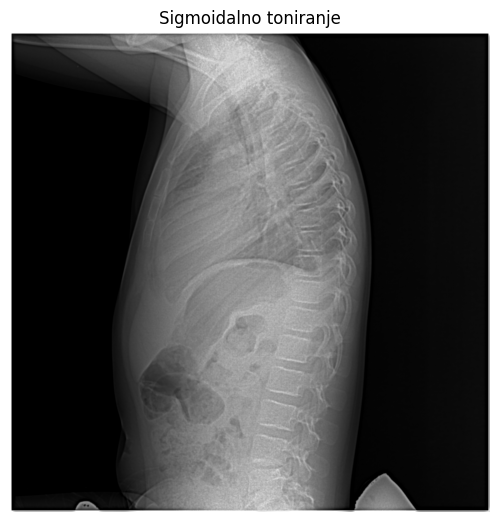

In [21]:
# 3.2
im_ts3 = ts_sigma(im_mse, [0.5, 3], 4096)

fig = plt.figure()
ax = fig.add_axes([0,0,1,1])
ax.imshow(im_ts3, cmap='gray', vmin=im_ts3.min(), vmax=im_ts3.max())
plt.axis('off')
plt.title('Sigmoidalno toniranje')
